In [1]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from cleaner import HouseCleaner

In [3]:
cleaner = HouseCleaner()

In [4]:
df_train = pd.read_csv(r'train.csv')
df_test = pd.read_csv(r'test.csv')

In [5]:
df_train.shape

(1241, 81)

In [6]:
X_train = df_train.drop('SalePrice', axis=1)
Y_train = df_train['SalePrice']

In [7]:
X_train_clean = cleaner.fit_transform(X_train)
X_test_clean = cleaner.transform(df_test)
feature_names = [f"f{i}" for i in range(X_train_clean.shape[1])]
X_train_df = pd.DataFrame(X_train_clean, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_clean, columns=feature_names, index=df_test.index)

In [8]:
print("X_train_clean is numeric:", np.issubdtype(X_train_clean.dtype, np.number))
print("X_train_clean has missing values:", np.isnan(X_train_clean).any())

X_train_clean is numeric: True
X_train_clean has missing values: False


In [9]:
X = pd.DataFrame(X_train_df, columns=feature_names)
Y = df_train['SalePrice']

In [10]:
X

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f185,f186,f187,f188,f189,f190,f191,f192,f193,f194
0,985.0,90.0,75.0,10125.0,5.0,5.0,1977.0,1977.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,778.0,20.0,100.0,13350.0,5.0,5.0,1974.0,1974.0,0.0,762.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,708.0,120.0,48.0,6240.0,8.0,5.0,2006.0,2006.0,176.0,863.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,599.0,20.0,80.0,12984.0,5.0,6.0,1977.0,1977.0,459.0,1283.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,875.0,50.0,52.0,5720.0,5.0,6.0,1941.0,1950.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1236,1096.0,20.0,78.0,9317.0,6.0,5.0,2006.0,2006.0,0.0,24.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1237,1131.0,50.0,65.0,7804.0,4.0,3.0,1928.0,1950.0,0.0,622.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1238,1295.0,20.0,60.0,8172.0,5.0,7.0,1955.0,1990.0,0.0,167.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1239,861.0,50.0,55.0,7642.0,7.0,8.0,1918.0,1998.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


<Axes: >

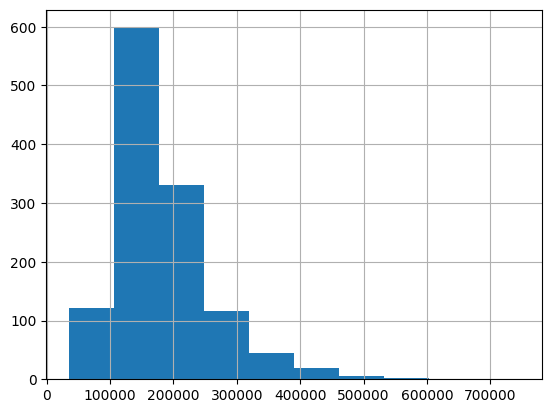

In [11]:
Y.hist()

<Axes: >

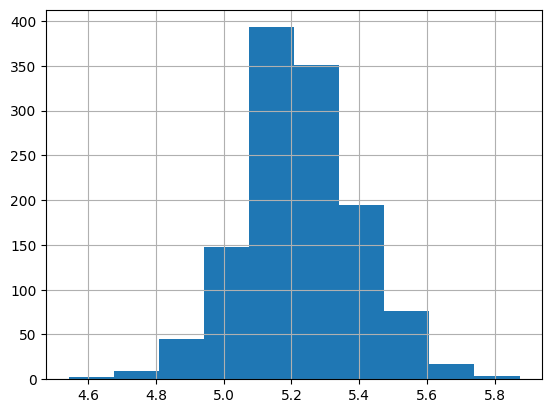

In [12]:
pd.Series(np.log10(Y)).hist()

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [15]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def printMetrics(y_valid, y_pred, model_name):
    print(f"Metrics for {model_name}:")
    print("MAE:", mean_absolute_error(y_valid, y_pred))
    print("MSE:", mean_squared_error(y_valid, y_pred))
    print("R2 Score:", r2_score(y_valid, y_pred))

In [17]:
lr = LinearRegression()
lr.fit(X_train, Y_train)
Y_pred_lr = lr.predict(X_test)
printMetrics(Y_test, Y_pred_lr, "Linear Regression Test Set")
print()
printMetrics(Y_train, lr.predict(X_train), "Linear Regression Train Set")


Metrics for Linear Regression Test Set:
MAE: 19866.142702409805
MSE: 957594907.2362641
R2 Score: 0.8658446211812918

Metrics for Linear Regression Train Set:
MAE: 14620.49389036326
MSE: 465403618.5409064
R2 Score: 0.9181360309409521


In [18]:
# submission_lr = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': lr.predict(X_test_df)
# })
# submission_lr.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_lr.csv', index=False)

In [19]:
from sklearn.model_selection import cross_val_score
cv_scores_lr = cross_val_score(lr, X, Y, cv=5, scoring='neg_mean_absolute_error')
print("Cross-Validation MAE Scores for Linear Regression:", -cv_scores_lr)
print("Average CV MAE for Linear Regression:", -cv_scores_lr.mean())

Cross-Validation MAE Scores for Linear Regression: [19304.15823833 19466.39794938 23076.8479904  21109.122951
 17628.28652078]
Average CV MAE for Linear Regression: 20116.9627299793


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV

model_ls_v1 = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, max_iter=50000))
])
cv_scores_ls = cross_val_score(model_ls_v1, X, Y, cv=5, scoring='neg_mean_absolute_error')
print("Cross-Validation MAE Scores for Lasso Regression:", -cv_scores_ls)
print("Average CV MAE for Lasso Regression:", -cv_scores_ls.mean())

Cross-Validation MAE Scores for Lasso Regression: [17407.20761963 17973.69433281 21347.95773396 18721.13007797
 16660.58921692]
Average CV MAE for Lasso Regression: 18422.11579625631


In [21]:
model_ls_v1.fit(X_train, Y_train)
Y_pred_ls = model_ls_v1.predict(X_test)
printMetrics(Y_test, Y_pred_ls, "Lasso Regression Test Set")
print()
printMetrics(Y_train, model_ls_v1.predict(X_train), "Lasso Regression Train Set")

Metrics for Lasso Regression Test Set:
MAE: 20828.529985466277
MSE: 1075774857.330544
R2 Score: 0.8492880628142134

Metrics for Lasso Regression Train Set:
MAE: 17816.896754874233
MSE: 771728088.2612938
R2 Score: 0.8642539038749053


In [22]:
# submission_ls_v1 = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': model_ls_v1.predict(X_test_df)
# })
# submission_ls_v1.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_ls_v1.csv', index=False)

In [23]:
"""
Conduct cross validation for Lasso regression to find the best alpha parameter. Then, train the model on the entire training set and evaluate it on the test set. Finally, create a submission file for the test set predictions.
"""
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=50000)
lasso_cv.fit(X_train, Y_train)
best_alpha = lasso_cv.alpha_
print("Best alpha for Lasso Regression:", best_alpha)

Best alpha for Lasso Regression: 100.0


In [24]:
model_ls_v2 = Lasso(alpha=best_alpha)
model_ls_v2.fit(X_train, Y_train)
Y_pred_ls_v2 = model_ls_v2.predict(X_test)
printMetrics(Y_test, Y_pred_ls_v2, "Lasso Regression with Best Alpha Test Set")
print()
printMetrics(Y_train, model_ls_v2.predict(X_train), "Lasso Regression with Best Alpha Train Set")

Metrics for Lasso Regression with Best Alpha Test Set:
MAE: 18228.35333379836
MSE: 852637654.5947194
R2 Score: 0.880548730279507

Metrics for Lasso Regression with Best Alpha Train Set:
MAE: 15697.674058404504
MSE: 548810717.6815962
R2 Score: 0.9034648167274376


/Users/macbook/Desktop/machine-learning-applications/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.550e+11, tolerance: 5.640e+08
  model = cd_fast.enet_coordinate_descent(


In [25]:
# submission_ls_v2 = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': model_ls_v2.predict(X_test_df)
# })
# submission_ls_v2.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_ls_v2.csv', index=False)

In [26]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

grid_lasso_param_grid = {
    'lasso__alpha': [0.1, 1, 5, 10, 20, 50, 100, 200],
    'lasso__max_iter': [50000, 100000]
}

grid_lasso = GridSearchCV(
    estimator=pipe,
    param_grid=grid_lasso_param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_lasso.fit(X_train, Y_train)

print("Best parameters:", grid_lasso.best_params_)
print("Best CV MAE:", -grid_lasso.best_score_)

/Users/macbook/Desktop/machine-learning-applications/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.476e+09, tolerance: 4.267e+08
  model = cd_fast.enet_coordinate_descent(
/Users/macbook/Desktop/machine-learning-applications/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.223e+09, tolerance: 4.717e+08
  model = cd_fast.enet_coordinate_descent(


Best parameters: {'lasso__alpha': 200, 'lasso__max_iter': 50000}
Best CV MAE: 20022.926781826587


In [27]:
model_ls_v3 = grid_lasso.best_estimator_
Y_pred_ls_v3 = model_ls_v3.predict(X_test)
printMetrics(Y_test, Y_pred_ls_v3, "Lasso Regression with Grid Search Best Parameters Test Set")
print()
printMetrics(Y_train, model_ls_v3.predict(X_train), "Lasso Regression with Grid Search Best Parameters Train Set")

Metrics for Lasso Regression with Grid Search Best Parameters Test Set:
MAE: 18897.19527588167
MSE: 891410799.04752
R2 Score: 0.8751167612467241

Metrics for Lasso Regression with Grid Search Best Parameters Train Set:
MAE: 14702.771898084475
MSE: 480884147.5742739
R2 Score: 0.9154130234280787


In [28]:
# submission_ls_v3 = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': model_ls_v3.predict(X_test_df)
# })
# submission_ls_v3.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_ls_v3.csv', index=False)

In [29]:
log_Y = np.log10(Y)

In [30]:
X_train_log, X_test_log, Y_train_log, Y_test_log = train_test_split(X, log_Y, test_size=0.2, random_state=42)

In [31]:
lr_log = LinearRegression()
lr_log.fit(X_train_log, Y_train_log)
Y_pred_lr_log = lr_log.predict(X_test_log)
printMetrics(Y_test_log, Y_pred_lr_log, "Linear Regression on Log-Transformed Target Test Set")
print()
printMetrics(Y_train_log, lr_log.predict(X_train_log), "Linear Regression on Log-Transformed Target Train Set")

Metrics for Linear Regression on Log-Transformed Target Test Set:
MAE: 0.038472991468017075
MSE: 0.0032658155024500985
R2 Score: 0.8899343065117707

Metrics for Linear Regression on Log-Transformed Target Train Set:
MAE: 0.03036359020087093
MSE: 0.0019047314515593461
R2 Score: 0.9338877194955988


In [32]:
# submission_lr_log = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': 10 ** lr_log.predict(X_test_df)
# })
# submission_lr_log.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_lr_log.csv', index=False)

In [33]:
model_ls_log_v1 = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, max_iter=50000))
])
cv_scores_ls_log = cross_val_score(model_ls_log_v1, X, log_Y, cv=5, scoring='neg_mean_absolute_error')
print("Cross-Validation MAE Scores for Lasso Regression on Log-Transformed Target:", -cv_scores_ls_log)
print("Average CV MAE for Lasso Regression on Log-Transformed Target:", -cv_scores_ls_log.mean())

Cross-Validation MAE Scores for Lasso Regression on Log-Transformed Target: [0.03545787 0.03767185 0.04541136 0.0356545  0.03265402]
Average CV MAE for Lasso Regression on Log-Transformed Target: 0.037369919163847506


In [34]:
model_ls_v1.fit(X_train_log, Y_train_log)
Y_pred_ls = model_ls_v1.predict(X_test_log)
printMetrics(Y_test_log, Y_pred_ls, "Lasso Regression Test Set")
print()
printMetrics(Y_train_log, model_ls_v1.predict(X_train_log), "Lasso Regression Train Set")

Metrics for Lasso Regression Test Set:
MAE: 0.03551072294583692
MSE: 0.0023650139275868598
R2 Score: 0.9202934465055115

Metrics for Lasso Regression Train Set:
MAE: 0.03424484598479567
MSE: 0.002377401099514661
R2 Score: 0.91748159131099


In [35]:
# submission_ls_log_v1 = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': 10 ** model_ls_v1.predict(X_test_df)
# })
# submission_ls_log_v1.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_ls_log_v1.csv', index=False)

In [36]:
from sklearn.linear_model import RidgeCV
model_rd_log_v1 = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(cv=5))
])
cv_scores_rd_log = cross_val_score(model_rd_log_v1, X, log_Y, cv=5, scoring='neg_mean_absolute_error')
print("Cross-Validation MAE Scores for Ridge Regression on Log-Transformed Target:", -cv_scores_rd_log)
print("Average CV MAE for Ridge Regression on Log-Transformed Target:", -cv_scores_rd_log.mean())

Cross-Validation MAE Scores for Ridge Regression on Log-Transformed Target: [0.03864    0.03903018 0.04681994 0.03913537 0.03538841]
Average CV MAE for Ridge Regression on Log-Transformed Target: 0.03980277938950386


In [37]:
model_rd_log_v1.fit(X_train_log, Y_train_log)
Y_pred_rd_log = model_rd_log_v1.predict(X_test_log)
printMetrics(Y_test_log, Y_pred_rd_log, "Ridge Regression on Log-Transformed Target Test Set")
print()
printMetrics(Y_train_log, model_rd_log_v1.predict(X_train_log), "Ridge Regression on Log-Transformed Target Train Set")

Metrics for Ridge Regression on Log-Transformed Target Test Set:
MAE: 0.03815562416735594
MSE: 0.0031051453756476377
R2 Score: 0.8953492691500727

Metrics for Ridge Regression on Log-Transformed Target Train Set:
MAE: 0.030457108311440332
MSE: 0.0019096802127941132
R2 Score: 0.9337159504566435


In [38]:
# submission_rd_log_v1 = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': 10 ** model_rd_log_v1.predict(X_test_df)
# })
# submission_rd_log_v1.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_rd_log_v1.csv', index=False)

In [39]:
from sklearn.tree import DecisionTreeRegressor

dt_v1 = DecisionTreeRegressor(random_state=42)
cv_scores_dt = cross_val_score(dt_v1, X, Y, cv=5, scoring='neg_mean_absolute_error')
print("Cross-Validation MAE Scores for Decision Tree Regression:", -cv_scores_dt)
print("Average CV MAE for Decision Tree Regression:", -cv_scores_dt.mean())

Cross-Validation MAE Scores for Decision Tree Regression: [28138.85542169 26231.33467742 31034.35080645 27510.87096774
 27638.66532258]
Average CV MAE for Decision Tree Regression: 28110.815439176058


In [40]:
dt_v1.fit(X_train, Y_train)
Y_pred_dt = dt_v1.predict(X_test)
printMetrics(Y_test, Y_pred_dt, "Decision Tree Regression Test Set")
print()
printMetrics(Y_train, dt_v1.predict(X_train), "Decision Tree Regression Train Set")

Metrics for Decision Tree Regression Test Set:
MAE: 27090.01204819277
MSE: 1484150709.7068274
R2 Score: 0.7920761700170058

Metrics for Decision Tree Regression Train Set:
MAE: 0.0
MSE: 0.0
R2 Score: 1.0


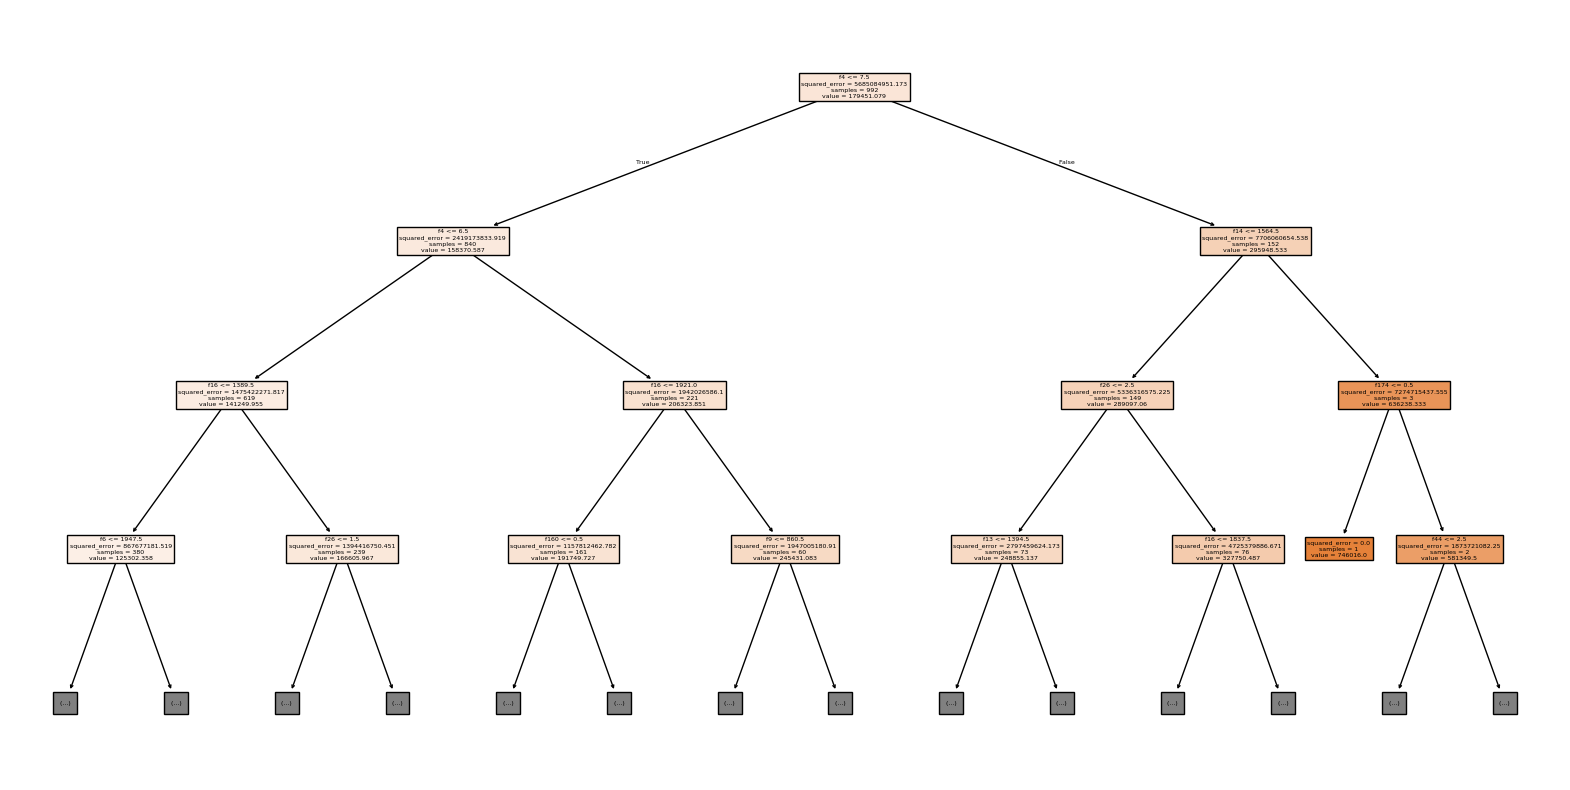

In [41]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(dt_v1, filled=True, feature_names=feature_names, max_depth=3)
plt.show()

In [42]:
param_grid_dt_v1 = {
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [5, 10, 20, 30, 50],
    "min_samples_leaf": [2, 4, 6, 10, 15],
    "max_leaf_nodes": [10, 20, 30, 50, None],
    "ccp_alpha": [0.0, 0.001, 0.01, 0.05, 0.1]
}

In [43]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_v1 = GridSearchCV(
    estimator=dt_v1,
    param_grid=param_grid_dt_v1,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_v1.fit(X_train, Y_train)

print("Best params:", grid_v1.best_params_)
print("Best CV score:", grid_v1.best_score_)
best_tree = grid_v1.best_estimator_

Fitting 5 folds for each of 4375 candidates, totalling 21875 fits
Best params: {'ccp_alpha': 0.0, 'max_depth': 10, 'max_leaf_nodes': None, 'min_samples_leaf': 6, 'min_samples_split': 5}
Best CV score: -25437.894026364935


In [44]:
best_tree.fit(X_train, Y_train)
Y_pred_best_tree = best_tree.predict(X_test)
printMetrics(Y_test, Y_pred_best_tree, "Best Decision Tree Regression Test Set")
print()
printMetrics(Y_train, best_tree.predict(X_train), "Best Decision Tree Regression Train Set")

Metrics for Best Decision Tree Regression Test Set:
MAE: 26288.152095639518
MSE: 1719360140.7230606
R2 Score: 0.7591242296074792

Metrics for Best Decision Tree Regression Train Set:
MAE: 13927.477549858399
MSE: 464839695.3405024
R2 Score: 0.9182352243928085


In [45]:
# submission_best_tree = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': best_tree.predict(X_test_df)
# })
# submission_best_tree.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_best_tree.csv', index=False)

In [46]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_v2 = GridSearchCV(
    estimator=dt_v1,
    param_grid=param_grid_dt_v1,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_v2.fit(X_train_log, Y_train_log)
print("Best params:", grid_v2.best_params_)
print("Best CV score:", grid_v2.best_score_)
best_tree_v2 = grid_v2.best_estimator_

Fitting 5 folds for each of 4375 candidates, totalling 21875 fits
Best params: {'ccp_alpha': 0.0, 'max_depth': 10, 'max_leaf_nodes': 50, 'min_samples_leaf': 15, 'min_samples_split': 5}
Best CV score: -0.08893489170617398


In [47]:
best_tree_v2.fit(X_train_log, Y_train_log)
Y_pred_best_tree_v2 = best_tree_v2.predict(X_test_log)
printMetrics(Y_test_log, Y_pred_best_tree_v2, "Best Decision Tree Regression on Log-Transformed Target Test Set")
print()
printMetrics(Y_train_log, best_tree_v2.predict(X_train_log), "Best Decision Tree Regression on Log-Transformed Target Train Set")

Metrics for Best Decision Tree Regression on Log-Transformed Target Test Set:
MAE: 0.06152641362253922
MSE: 0.00747251547789114
R2 Score: 0.7481585847214642

Metrics for Best Decision Tree Regression on Log-Transformed Target Train Set:
MAE: 0.047934487342898686
MSE: 0.004284807394739159
R2 Score: 0.8512764683145141


In [48]:
from sklearn.ensemble import RandomForestRegressor
rf_v1 = RandomForestRegressor(random_state=42)
cv_scores_rf = cross_val_score(rf_v1, X, Y, cv=5, scoring='neg_mean_absolute_error')
print("Cross-Validation MAE Scores for Random Forest Regression:", -cv_scores_rf)
print("Average CV MAE for Random Forest Regression:", -cv_scores_rf.mean())

Cross-Validation MAE Scores for Random Forest Regression: [17644.2624498  18382.30923387 22358.0541129  17137.26
 16115.39709677]
Average CV MAE for Random Forest Regression: 18327.456578669517


In [49]:
rf_v1.fit(X_train, Y_train)
Y_pred_rf = rf_v1.predict(X_test)
printMetrics(Y_test, Y_pred_rf, "Random Forest Regression Test Set")
print()
printMetrics(Y_train, rf_v1.predict(X_train), "Random Forest Regression Train Set")

Metrics for Random Forest Regression Test Set:
MAE: 17993.506265060238
MSE: 928693145.0258569
R2 Score: 0.8698936473703052

Metrics for Random Forest Regression Train Set:
MAE: 6637.055776209677
MSE: 126628615.64532669
R2 Score: 0.9777261700162996


In [50]:
submission_rf_v1 = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': rf_v1.predict(X_test_df)
})
submission_rf_v1.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_rf_v1.csv', index=False)

In [51]:
param_grid_rf_v1 = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ['sqrt', 'log2']
}

grid_rf_v1 = GridSearchCV(
    estimator=rf_v1,
    param_grid=param_grid_rf_v1,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=4,   # or 2
    verbose=1
)
grid_rf_v1.fit(X_train, Y_train)
print("Best parameters for Random Forest:", grid_rf_v1.best_params_)
print("Best CV MAE for Random Forest:", -grid_rf_v1.best_score_)
best_rf = grid_rf_v1.best_estimator_

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters for Random Forest: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV MAE for Random Forest: 18465.131691479164


In [52]:
best_rf.fit(X_train, Y_train)
Y_pred_best_rf = best_rf.predict(X_test)
printMetrics(Y_test, Y_pred_best_rf, "Best Random Forest Regression Test Set")
print()
printMetrics(Y_train, best_rf.predict(X_train), "Best Random Forest Regression Train Set")

Metrics for Best Random Forest Regression Test Set:
MAE: 19528.39315603533
MSE: 1103202643.4845972
R2 Score: 0.8454455350252184

Metrics for Best Random Forest Regression Train Set:
MAE: 6520.238962129968
MSE: 126036879.66770157
R2 Score: 0.977830255704149


In [53]:
# submission_best_rf = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': best_rf.predict(X_test_df)
# })
# submission_best_rf.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_best_rf.csv', index=False)

In [54]:
param_grid_rf_log_v1 = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ['sqrt', 'log2']
}

grid_rf_log_v1 = GridSearchCV(
    estimator=rf_v1,
    param_grid=param_grid_rf_log_v1,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=4,   # or 2
    verbose=1
)
grid_rf_log_v1.fit(X_train_log, Y_train_log)
print("Best parameters for Random Forest:", grid_rf_log_v1.best_params_)
print("Best CV MAE for Random Forest:", -grid_rf_log_v1.best_score_)
best_rf = grid_rf_log_v1.best_estimator_

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV MAE for Random Forest: 0.044816596129745125


In [55]:
best_rf.fit(X_train_log, Y_train_log)
Y_pred_best_rf = best_rf.predict(X_test_log)
printMetrics(Y_test_log, Y_pred_best_rf, "Best Random Forest Regression on Log-Transformed Target Test Set")
print()
printMetrics(Y_train_log, best_rf.predict(X_train_log), "Best Random Forest Regression on Log-Transformed Target Train Set")

Metrics for Best Random Forest Regression on Log-Transformed Target Test Set:
MAE: 0.0425616952876305
MSE: 0.003820329464664615
R2 Score: 0.8712458766986787

Metrics for Best Random Forest Regression on Log-Transformed Target Train Set:
MAE: 0.015981332316494127
MSE: 0.0005707571554802139
R2 Score: 0.9801893032573645


In [56]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    "n_estimators": [100, 200, 300, 500, 700, 1000],
    "max_depth": [None, 5, 10, 20, 30, 40, 50],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "max_features": [1.0, "sqrt", "log2", None],
    "bootstrap": [True, False]
}

random_rf = RandomizedSearchCV(
    estimator=rf_v1,
    param_distributions=param_dist_rf,
    n_iter=40,                  # try 20 first if your Mac is slow
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=4,                   # safer than -1 on Mac
    verbose=1,
    random_state=42
)

random_rf.fit(X_train, Y_train)

print("Best parameters for Random Forest:", random_rf.best_params_)
print("Best CV MAE for Random Forest:", -random_rf.best_score_)

best_rf = random_rf.best_estimator_

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best parameters for Random Forest: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': True}
Best CV MAE for Random Forest: 18613.948387254986


In [57]:
best_rf.fit(X_train, Y_train)
Y_pred_best_rf = best_rf.predict(X_test)
printMetrics(Y_test, Y_pred_best_rf, "Best Random Forest Regression Test Set")
print()
printMetrics(Y_train, best_rf.predict(X_train), "Best Random Forest Regression Train Set")

Metrics for Best Random Forest Regression Test Set:
MAE: 19533.256194677437
MSE: 1101607926.7379968
R2 Score: 0.8456689487334911

Metrics for Best Random Forest Regression Train Set:
MAE: 8714.133523812186
MSE: 223596878.79204708
R2 Score: 0.9606695624230026


In [58]:
# submission_best_rf_rs_v1 = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': best_rf.predict(X_test_df)
# })
# submission_best_rf_rs_v1.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_best_rf_rs_v1.csv', index=False)

In [59]:
from sklearn.impute import SimpleImputer
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        oob_score=True
    ))
])


param_dist = {
    "rf__n_estimators": [200, 300, 500, 700, 1000],
    "rf__max_depth": [None, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20],
    "rf__min_samples_leaf": [1, 2, 4, 6, 8, 10],
    "rf__max_features": ["sqrt", "log2", 0.5, 0.7, 1.0],
    "rf__bootstrap": [True],
    "rf__max_samples": [0.6, 0.7, 0.8, 0.9, None]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_mean_absolute_error",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

In [60]:
random_search.fit(X_train, Y_train)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV MAE:")
print(-random_search.best_score_)

best_rf = random_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END rf__bootstrap=True, rf__max_depth=20, rf__max_features=log2, rf__max_samples=0.6, rf__min_samples_leaf=2, rf__min_samples_split=20, rf__n_estimators=200; total time=   0.3s
[CV] END rf__bootstrap=True, rf__max_depth=20, rf__max_features=log2, rf__max_samples=0.6, rf__min_samples_leaf=2, rf__min_samples_split=20, rf__n_estimators=200; total time=   0.3s
[CV] END rf__bootstrap=True, rf__max_depth=20, rf__max_features=log2, rf__max_samples=0.6, rf__min_samples_leaf=2, rf__min_samples_split=20, rf__n_estimators=200; total time=   0.3s
[CV] END rf__bootstrap=True, rf__max_depth=None, rf__max_features=log2, rf__max_samples=0.6, rf__min_samples_leaf=8, rf__min_samples_split=10, rf__n_estimators=200; total time=   0.3s
[CV] END rf__bootstrap=True, rf__max_depth=None, rf__max_features=log2, rf__max_samples=0.6, rf__min_samples_leaf=8, rf__min_samples_split=10, rf__n_estimators=200; total time=   0.3s
[CV] END rf__bootstrap=T

In [61]:
best_rf.fit(X_train, Y_train)
Y_pred_best_rf = best_rf.predict(X_test)
printMetrics(Y_test, Y_pred_best_rf, "Best Random Forest Regression Test Set")
print()
printMetrics(Y_train, best_rf.predict(X_train), "Best Random Forest Regression Train Set")

Metrics for Best Random Forest Regression Test Set:
MAE: 18324.412272314992
MSE: 975494544.4844402
R2 Score: 0.8633369505602386

Metrics for Best Random Forest Regression Train Set:
MAE: 9655.839510256277
MSE: 298249153.46195614
R2 Score: 0.9475383119120488


In [62]:
# submission_rf_v4 = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': best_rf.predict(X_test_df)
# })
# submission_rf_v4.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_rf_v4.csv', index=False)

In [63]:
from sklearn.ensemble import GradientBoostingRegressor

gb_v1 = GradientBoostingRegressor(random_state=42)
cv_scores_gb = cross_val_score(gb_v1, X_train, Y_train, cv=5, scoring='neg_mean_absolute_error')
print("Cross-Validation MAE Scores for Gradient Boosting Regression:", -cv_scores_gb)
print("Average CV MAE for Gradient Boosting Regression:", -cv_scores_gb.mean())

Cross-Validation MAE Scores for Gradient Boosting Regression: [17361.99729239 15090.4438921  19389.3248281  15604.73065194
 18430.89447715]
Average CV MAE for Gradient Boosting Regression: 17175.478228334967


In [64]:
gb_v1.fit(X_train, Y_train)
Y_pred_gb = gb_v1.predict(X_test)
printMetrics(Y_test, Y_pred_gb, "Gradient Boosting Regression Test Set")
print()
printMetrics(Y_train, gb_v1.predict(X_train), "Gradient Boosting Regression Train Set")

Metrics for Gradient Boosting Regression Test Set:
MAE: 17045.180537592707
MSE: 831883410.6026043
R2 Score: 0.8834563203719542

Metrics for Gradient Boosting Regression Train Set:
MAE: 9879.161807664934
MSE: 175591805.8035397
R2 Score: 0.9691136003574929


In [65]:
from scipy.stats import randint, uniform, loguniform
gb_base = GradientBoostingRegressor(
    random_state=42,
    validation_fraction=0.1,
    n_iter_no_change=10,
    tol=1e-4
)

param_dist_gb = {
    "learning_rate": loguniform(0.01, 0.10),
    "n_estimators": randint(100, 600),

    "max_depth": randint(1, 4),              # 1, 2, 3
    "min_samples_split": randint(10, 41),    # 10 ... 40
    "min_samples_leaf": randint(3, 21),      # 3 ... 20

    "subsample": uniform(0.60, 0.35),        # 0.60 ... 0.95
    "max_features": [None, "sqrt", "log2", 0.7, 0.8],

    "loss": ["squared_error", "huber"],
    "ccp_alpha": [0.0, 1e-4, 1e-3, 1e-2]
}

In [66]:
random_gb = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_dist_gb,
    n_iter=80,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

random_gb.fit(X_train, Y_train)

best_gb = random_gb.best_estimator_

Fitting 5 folds for each of 80 candidates, totalling 400 fits


In [67]:
best_gb.fit(X_train, Y_train)
Y_pred_best_gb = best_gb.predict(X_test)
printMetrics(Y_test, Y_pred_best_gb, "Best Gradient Boosting Regression Test Set")
print()
printMetrics(Y_train, best_gb.predict(X_train), "Best Gradient Boosting Regression Train Set")

Metrics for Best Gradient Boosting Regression Test Set:
MAE: 15803.609689921617
MSE: 717322257.8340667
R2 Score: 0.8995058990940549

Metrics for Best Gradient Boosting Regression Train Set:
MAE: 10651.574412064441
MSE: 464479592.8253117
R2 Score: 0.918298566017126


In [68]:
# submission_best_gb_v1 = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': best_gb.predict(X_test_df)
# })
# submission_best_gb_v1.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_best_gb_v1.csv', index=False)

In [69]:
gb_v2 = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=2,
    min_samples_split=20,
    min_samples_leaf=8,
    subsample=0.75,
    max_features="sqrt",
    loss="huber",
    validation_fraction=0.1,
    n_iter_no_change=10,
    tol=1e-4,
    random_state=42
)

In [70]:
random_gb = RandomizedSearchCV(
    estimator=gb_v2,
    param_distributions=param_dist_gb,
    n_iter=80,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

random_gb.fit(X_train, Y_train)

best_gb = random_gb.best_estimator_

Fitting 5 folds for each of 80 candidates, totalling 400 fits


In [71]:
best_gb.fit(X_train, Y_train)
Y_pred_best_gb = best_gb.predict(X_test)
printMetrics(Y_test, Y_pred_best_gb, "2nd Best Gradient Boosting Regression Test Set")
print()
printMetrics(Y_train, best_gb.predict(X_train), "2nd Best Gradient Boosting Regression Train Set")

Metrics for 2nd Best Gradient Boosting Regression Test Set:
MAE: 15803.609689921617
MSE: 717322257.8340667
R2 Score: 0.8995058990940549

Metrics for 2nd Best Gradient Boosting Regression Train Set:
MAE: 10651.574412064441
MSE: 464479592.8253117
R2 Score: 0.918298566017126


In [72]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_dist_gb = {
    "learning_rate": loguniform(0.01, 0.08),
    "n_estimators": randint(150, 700),

    "max_depth": randint(1, 4),             # 1,2,3
    "min_samples_split": randint(10, 41),
    "min_samples_leaf": randint(3, 21),

    "subsample": uniform(0.60, 0.30),       # 0.60 to 0.90
    "max_features": [None, "sqrt", "log2", 0.7, 0.8],

    "loss": ["squared_error", "huber"],
    "ccp_alpha": [0.0, 1e-4, 1e-3, 1e-2]
}

base_gb = GradientBoostingRegressor(
    validation_fraction=0.1,
    n_iter_no_change=10,
    tol=1e-4
)

n_runs = 6
n_iter_per_run = 80

all_run_results = []
all_searches = []

for run in range(n_runs):
    seed = 42 + run

    search = RandomizedSearchCV(
        estimator=base_gb,
        param_distributions=param_dist_gb,
        n_iter=n_iter_per_run,
        scoring="neg_mean_absolute_error",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        random_state=seed,
        return_train_score=True,
        refit=True
    )

    search.fit(X_train, Y_train)

    best_idx = search.best_index_

    cv_mae = -search.cv_results_["mean_test_score"][best_idx]
    train_mae = -search.cv_results_["mean_train_score"][best_idx]
    gap = cv_mae - train_mae


    objective = cv_mae + 0.35 * gap

    all_run_results.append({
        "run": run + 1,
        "seed": seed,
        "cv_mae": cv_mae,
        "train_mae": train_mae,
        "gap": gap,
        "objective": objective,
        "best_params": search.best_params_
    })

    all_searches.append(search)

results_df = pd.DataFrame(all_run_results).sort_values(
    by=["objective", "cv_mae", "gap"],
    ascending=[True, True, True]
).reset_index(drop=True)

print("Summary of repeated randomized searches:")
print(results_df[["run", "seed", "cv_mae", "train_mae", "gap", "objective"]])

best_run_number = int(results_df.loc[0, "run"]) - 1
champion_search = all_searches[best_run_number]
best_gb = champion_search.best_estimator_

print("\nChampion search params:")
print(champion_search.best_params_)
print("Champion CV MAE:", -champion_search.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Summary of repeated randomized searches:
   run  seed        cv_mae     train_mae          gap     objective
0    3    44  16086.205514  12264.368468  3821.837046  17423.848480
1    2    43  16279.978804  12410.176899  3869.801905  17634.409471
2    5    46  16215.358010  11144.967559  5070.390451  17989.994668
3    4    45  16303.103762  11072.901471  5230.202291  18133.674564
4    6    47  16496.105085  11420.024166  5076.080919  18272.733406
5    1    42  16164.016606   9476.589002  6687.427604  18504.616268

Champion search params:
{'ccp_alpha': 0.0, 'learning_rate': np.float64(0.06980186581035468), 'loss': 'huber', 

In [73]:
best_gb.fit(X_test, Y_test)
Y_pred_best_gb = best_gb.predict(X_test)
printMetrics(Y_test, Y_pred_best_gb, "3nd Best Gradient Boosting Regression Test Set")
print()
printMetrics(Y_train, best_gb.predict(X_train), "3nd Best Gradient Boosting Regression Train Set")

Metrics for 3nd Best Gradient Boosting Regression Test Set:
MAE: 14999.286475295881
MSE: 678317200.1811886
R2 Score: 0.9049703582779176

Metrics for 3nd Best Gradient Boosting Regression Train Set:
MAE: 19203.00507007686
MSE: 948585779.5512892
R2 Score: 0.8331448364099597


In [74]:
# submission_best_gb_v2 = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': best_gb.predict(X_test_df)
# })
# submission_best_gb_v2.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_best_gb_v2.csv', index=False)

In [75]:
from sklearn.ensemble import AdaBoostRegressor
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
ab_v1 = AdaBoostRegressor()
cv_scores_ab = cross_val_score(
    ab_v1, X, Y, cv=cv_strategy, scoring='neg_mean_absolute_error'
)
print("Cross-Validation MAE Scores for AdaBoost Regression:", -cv_scores_ab)
print("Average CV MAE for AdaBoost Regression:", -cv_scores_ab.mean())


Cross-Validation MAE Scores for AdaBoost Regression: [24790.36563386 23031.73964663 23379.61120806 23774.96255797
 24286.61394743]
Average CV MAE for AdaBoost Regression: 23852.658598790073


In [76]:
ab_v1.fit(X_train, Y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [77]:
Y_pred_ab_v1 = ab_v1.predict(X_test)
printMetrics(Y_test, Y_pred_ab_v1, "Best AdaBoost Regression Test Set")
print()
printMetrics(Y_train, ab_v1.predict(X_train), "Best AdaBoost Regression Train Set")

Metrics for Best AdaBoost Regression Test Set:
MAE: 24712.095030730397
MSE: 1334219251.3749397
R2 Score: 0.8130809930766935

Metrics for Best AdaBoost Regression Train Set:
MAE: 21237.458053236263
MSE: 735228553.5162039
R2 Score: 0.8706741306716144


In [78]:
# submission_ab_v1 = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': ab_v1.predict(X_test_df)
# })
# submission_ab_v1.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_ab_v1.csv', index=False)

In [79]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# Base estimator (weak learner)
base_tree = DecisionTreeRegressor(random_state=42)

# AdaBoost model
ab_model = AdaBoostRegressor(
    estimator=base_tree,   # if older sklearn gives error, use base_estimator=base_tree
    random_state=42
)

# Hyperparameter space
param_dist_ab = {
    "n_estimators": randint(50, 1000),
    "learning_rate": loguniform(1e-3, 1.0),
    "loss": ["linear", "square", "exponential"],

    # Parameters of the base DecisionTreeRegressor
    "estimator__max_depth": randint(1, 8),
    "estimator__min_samples_split": randint(2, 25),
    "estimator__min_samples_leaf": randint(1, 15),
    "estimator__max_features": [None, "sqrt", "log2", 0.5, 0.8]
}

# Randomized search
random_ab = RandomizedSearchCV(
    estimator=ab_model,
    param_distributions=param_dist_ab,
    n_iter=100,
    scoring="neg_mean_absolute_error",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

# Fit search
random_ab.fit(X, Y)

# Best model
best_ab = random_ab.best_estimator_

print("Best Parameters for AdaBoost Regression:")
print(random_ab.best_params_)

print("\nBest CV MAE for AdaBoost Regression:")
print(-random_ab.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters for AdaBoost Regression:
{'estimator__max_depth': 7, 'estimator__max_features': 0.8, 'estimator__min_samples_leaf': 3, 'estimator__min_samples_split': 13, 'learning_rate': np.float64(0.08178476574339538), 'loss': 'exponential', 'n_estimators': 596}

Best CV MAE for AdaBoost Regression:
18551.005463263064


In [80]:
best_ab.fit(X_train, Y_train)
Y_pred_best_ab = best_ab.predict(X_test)
printMetrics(Y_test, Y_pred_ab_v1, "Best AdaBoost Regression Test Set")
print()
printMetrics(Y_train, best_ab.predict(X_train), "Best AdaBoost Regression Train Set")

Metrics for Best AdaBoost Regression Test Set:
MAE: 24712.095030730397
MSE: 1334219251.3749397
R2 Score: 0.8130809930766935

Metrics for Best AdaBoost Regression Train Set:
MAE: 8961.833424688573
MSE: 114118035.6379401
R2 Score: 0.9799267668613485


In [81]:
from xgboost import XGBRegressor

In [82]:
xgb = XGBRegressor()
xgb.fit(X_train, Y_train)
xgb_pred_v1 = xgb.predict(X_test)

In [83]:
printMetrics(Y_test, xgb_pred_v1, "XGB Regression Test Set")
print()
printMetrics(Y_train, xgb.predict(X_train), "XGB Regression Train Set")

Metrics for XGB Regression Test Set:
MAE: 18111.8828125
MSE: 887378752.0
R2 Score: 0.8756816387176514

Metrics for XGB Regression Train Set:
MAE: 552.1431274414062
MSE: 640183.375
R2 Score: 0.9998874068260193


In [84]:
# submission_xgb_v1 = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': xgb.predict(X_test_df)
# })
# submission_xgb_v1.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_xgb_v1.csv', index=False)

In [85]:
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="mae",
    tree_method="hist",
    random_state=42,
    n_jobs=1
)

param_dist = {
    "n_estimators": randint(300, 1800),
    "learning_rate": loguniform(0.01, 0.15),
    "max_depth": randint(2, 7),     
    "min_child_weight": randint(2, 16),    
    "subsample": uniform(0.60, 0.35),     
    "colsample_bytree": uniform(0.60, 0.35), 
    "gamma": loguniform(1e-4, 5.0),        
    "reg_alpha": loguniform(1e-4, 10.0),    
    "reg_lambda": loguniform(0.5, 30.0)     
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

random_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=80,
    scoring="neg_mean_absolute_error",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=2,
    return_train_score=True
)

random_xgb.fit(X_train, Y_train)

print("Best params:", random_xgb.best_params_)
print("Best CV MAE:", -random_xgb.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'colsample_bytree': np.float64(0.732295656542789), 'gamma': np.float64(0.2056696828445207), 'learning_rate': np.float64(0.01961201893792465), 'max_depth': 4, 'min_child_weight': 8, 'n_estimators': 1449, 'reg_alpha': np.float64(0.029048621075181583), 'reg_lambda': np.float64(0.5237915669211286), 'subsample': np.float64(0.7640312246979442)}
Best CV MAE: 15824.7298828125


In [89]:
best_params = random_xgb.best_params_.copy()
best_params["n_estimators"] = 5000

final_xgb = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="mae",
    tree_method="hist",
    random_state=42,
    n_jobs=2,
    **best_params
)

final_xgb.fit(
    X_train,
    Y_train,
    eval_set=[(X_test, Y_test)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,np.float64(0.732295656542789)
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.data

In [90]:
Y_pred_final_xgb = final_xgb.predict(X_test)
printMetrics(Y_test, Y_pred_final_xgb, "Randomized XGB Regression Test Set")
print()
printMetrics(Y_train, final_xgb.predict(X_train), "Randomized XGB Regression Train Set")

Metrics for Randomized XGB Regression Test Set:
MAE: 15316.1025390625
MSE: 647450112.0
R2 Score: 0.9092947244644165

Metrics for Randomized XGB Regression Train Set:
MAE: 716.9190063476562
MSE: 995177.875
R2 Score: 0.9998249411582947


In [ ]:
# submission_final_xgb = pd.DataFrame({
#     'Id': df_test['Id'],
#     'SalePrice': final_xgb.predict(X_test_df)
# })
# submission_final_xgb.to_csv('/Users/macbook/Desktop/viral-data-ml/submission_final_xgb.csv', index=False)